# 14 - Scrambled MNIST: proving FNNs ignore geometry

**Section:** FNNs | **Prereqs:** `FNNs/MinMaxMNIST.ipynb` | **Next:** `FNNs/ShiftedMNIST.ipynb`

Apply one fixed random permutation to the 784 pixel positions - the same shuffle
for every image - and retrain. The images become unrecognisable to a human.
Accuracy does not change at all.

**Why.** A fully connected layer computes `W @ x`, a weighted sum over all
inputs. Permuting the inputs just permutes the columns of `W`, and the model
learns the permuted columns exactly as easily. An FNN never knew which pixels
were adjacent, so it cannot lose that knowledge.

**Why it matters.** This is the precise argument for convolution. A CNN's kernel
slides over a local neighbourhood, so it *does* encode adjacency - and it would
be destroyed by this same scramble. That contrast is the whole motivation for
the `CNNs/` section.

**Bonus:** this notebook scales the test set correctly with `scaler.transform`,
unlike `MinMaxMNIST.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset,DataLoader

from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST
%matplotlib inline

In [2]:
data = MNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # Load the training set
    download=True,
    transform = ToTensor()
)

test_data =  MNIST(
    root='./data',        # Directory to store the dataset
    train=False,           # Load the training set
    download=True,
    transform = ToTensor()
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.07MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.44MB/s]


In [3]:
# Flatten both splits to 784-vectors.
label = data.targets.to('cuda')
data = data.data.view(-1,784)

test_label = test_data.targets.to('cuda')
test_data = test_data.data.view(-1,784)

In [4]:
# Correct scaling: fit on TRAIN, then apply the same transform to test.
# Compare with MinMaxMNIST.ipynb, which re-fits on the test set.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data = scaler.fit_transform(data)

test_data = scaler.transform(test_data)


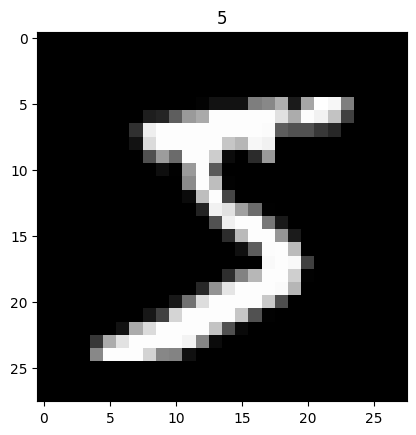

In [5]:
# The digit before scrambling.
plt.imshow(data[0].reshape(28,28),cmap='grey')
plt.title(label[0].item());

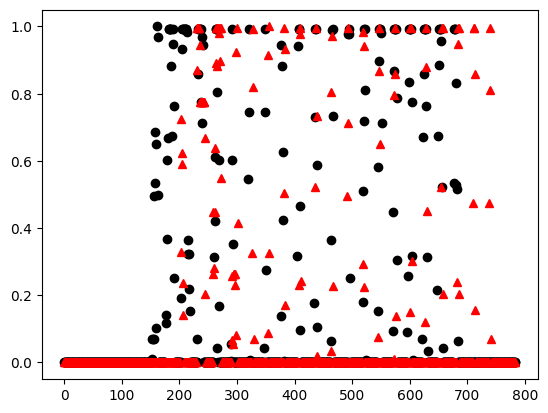

In [6]:
# Train (black) and test (red) pixel profiles overlaid - similar distributions,
# a quick check that the two splits really do come from the same source.
plt.plot(data[0],'ko')
plt.plot(test_data[0],'r^');

In [7]:
# THE EXPERIMENT: one random permutation of the 784 columns, applied to train
# and test alike. Same permutation for every image, so the mapping is a
# consistent relabelling of features, not added noise.
# Now adding random permutations

permutations = np.random.permutation(data.shape[1])

data = data[:,permutations]
test_data = test_data[:,permutations]

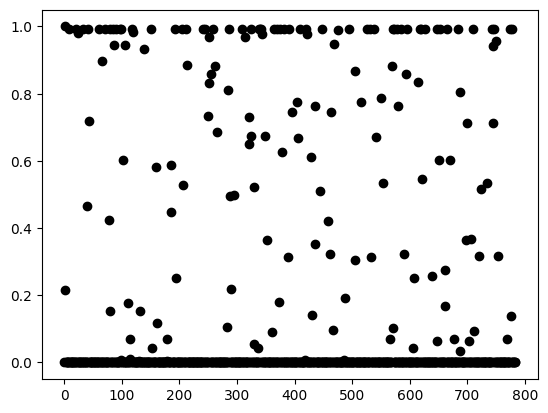

In [8]:
# The pixel values are the same multiset as before - only their order changed.
plt.plot(data[0],'ko');

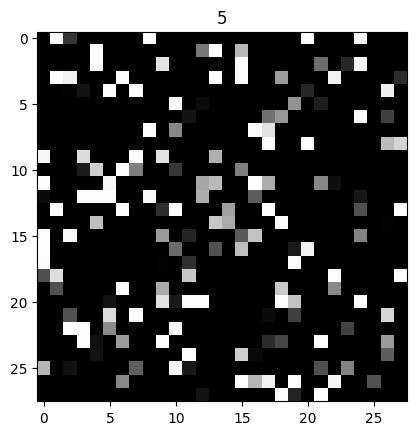

In [9]:
# Reshaped to 28x28 it is visual noise. No human could label this. The network
# will hit the same accuracy as on the unscrambled data.
plt.imshow(data[0].reshape(28,28),cmap='grey')
plt.title(label[0].item());

In [10]:
# Tensors on GPU, loaders as usual. Smaller batch size (16) here.
# Now lets get the data sorted on the GPU()

data = torch.tensor(data,dtype=torch.float,device='cuda')
test_data = torch.tensor(test_data,dtype=torch.float,device='cuda')

train_data = TensorDataset(data,label)
test_data = TensorDataset(test_data,test_label)


bs = 16
train_loader = DataLoader(train_data,batch_size=bs, shuffle=True,drop_last=True)
test_loader = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

In [12]:
# Shape check: still 784 features per sample.
test_loader.dataset.tensors[0][0,:].shape

torch.Size([784])

In [ ]:
# 784-128-128-10, raw logits.
class classifier(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784,128)
    self.fc1 = nn.Linear(128,128)
    self.output_layer = nn.Linear(128,10)

  def forward(self,x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.fc1(x))

    return self.output_layer(x)

In [ ]:
# Standard training function.
def train_model():

  model = classifier().to('cuda')

  lr = 1e-4
  lossFunc = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr = lr)
  epochs = 50

  test_acc= []
  train_acc = []
  losses = []

  for epoch in range(epochs):

    model.train()
    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = model(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append( 100 * torch.mean( (torch.argmax(yhat,dim=1) == y).float() ).cpu() )


    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    if epoch % 10 == 0 or epoch == epochs - 1:
      print(f'Epoch {epoch} | Loss : {losses[epoch]}')

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      preds = model(X)
      test_acc.append( 100 * torch.mean( (torch.argmax(preds,dim=1) == Y).float() ).cpu() )


  return train_acc, test_acc,losses

In [ ]:
# Train it. Watch the accuracy: it lands where the unscrambled runs did.
train_acc, test_acc,losses = train_model()

Epoch 0 | Loss : 0.5230823158408204
Epoch 10 | Loss : 0.06488233596722906
Epoch 20 | Loss : 0.022809849726520285
Epoch 30 | Loss : 0.007262339038604993
Epoch 40 | Loss : 0.002624719152175546
Epoch 49 | Loss : 0.001213298690776349


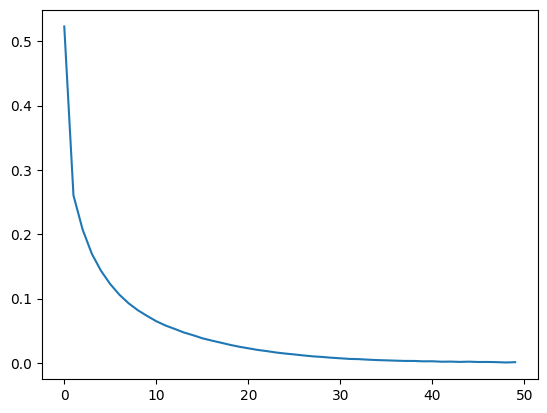

In [ ]:
# Loss curve - as clean as on the original data.
plt.plot(losses);

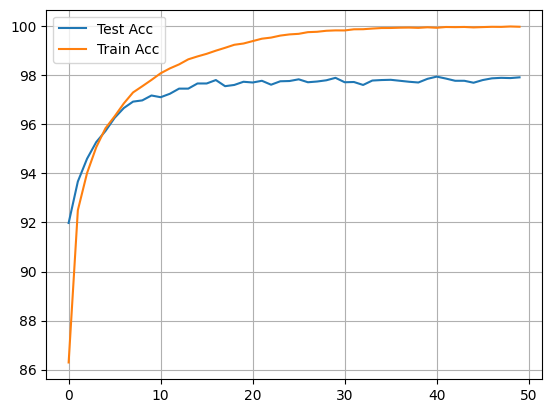

In [ ]:
# Train and test accuracy, unaffected by the scramble. This is the result.
plt.plot(test_acc,label="Test Acc")
plt.plot(train_acc, label="Train Acc")
plt.grid()
plt.legend();

In [ ]:
# Final numbers, for comparison with MNIST.ipynb.
# Conclusion: an FNN treats an image as an unordered bag of 784 numbers.
# Spatial structure is information it never uses - and CNNs exist to use it.
train_acc[-1], test_acc[-1]

(np.float32(99.98333), tensor(97.9200))

## Now the conclusion is that FNNs don't actually leverage spatial information, but they just learn abstract relationships between pixels.


#### This means that it does not matter how the data is structured in space for eg a picture where pixels are n X n . FNNs only consider the total pixels which are n^2.


